# Diel Carbonate–Isotope Model (Freshwater)

This notebook simulates a 24-hour (diel) cycle of the dissolved inorganic carbon (DIC) system in a well-mixed surface layer, tracking **12C and 13C** in **CO₂(aq), HCO₃⁻, CO₃²⁻** with:

- **Wind-dependent gas transfer** (\(k\)) via k₆₀₀ parameterizations and Schmidt-number scaling
- **Photosynthetic uptake** split between **CO₂** and **HCO₃⁻** with distinct fractionations (εₚ)
- **Respiration** adding CO₂ with a chosen isotopic signature
- **Kinetic fractionation** during **invasion/evasion**
- **Carbonate speciation** and **pH** solved each step from **DIC** and **TA** (freshwater TA definition)

> Dependencies: **NumPy**, **Matplotlib** (no internet required). TA is held constant as a first-order assumption for diel cycles.


## 1) Imports and global constants

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

# VPDB standard 13C/12C ratio
R_STD = 0.0111802

# Freshwater carbonate constants (didactic, ~25 °C)
pK1, pK2, pKw = 6.3, 10.3, 14.0
K1, K2, Kw = 10**(-pK1), 10**(-pK2), 10**(-pKw)

# Equilibrium isotope fractionation among species (relative to CO2)
alpha_eq_HCO3 = 1.009   # +9 ‰ vs CO2
alpha_eq_CO3  = 1.018   # +18 ‰ vs CO2

# Gas-exchange kinetic isotope effects
eps_inv = -1.0; alpha_inv = 1.0 + eps_inv / 1000.0   # invasion
eps_eva = +9.0; alpha_eva = 1.0 + eps_eva / 1000.0   # evasion

# Photosynthetic fractionations (set separately for species)
eps_p_CO2  = -20.0; alpha_p_CO2  = 1.0 + eps_p_CO2  / 1000.0
eps_p_HCO3 = -10.0; alpha_p_HCO3 = 1.0 + eps_p_HCO3 / 1000.0


## 2) Helper functions (δ ↔ R, solubility, speciation, isotope partition, wind → k)

In [2]:
def delta_to_R(delta_permil: float) -> float:
    return R_STD * (1.0 + delta_permil / 1000.0)

def R_to_delta(R: float) -> float:
    return 1000.0 * (R / R_STD - 1.0)

def f13_from_R(R: float) -> float:
    """Fraction of 13C given 13C/12C = R."""
    return R / (1.0 + R)

def K0_CO2_Weiss(T_C: float, S: float = 0.0) -> float:
    """
    Weiss (1974) CO2 solubility in water/seawater (mol L^-1 atm^-1).
    T in °C; S in PSU (0 for freshwater).
    """
    T_K = T_C + 273.15
    A1, A2, A3 = -58.0931, 90.5069, 22.2940
    B1, B2, B3 = 0.027766, -0.025888, 0.0050578
    lnK0 = (A1 + A2 * (100.0 / T_K) + A3 * math.log(T_K / 100.0) +
            S * (B1 + B2 * (T_K / 100.0) + B3 * (T_K / 100.0) ** 2))
    return math.exp(lnK0)

def speciate_carbonate(DIC_mol_L: float, TA_mol_L: float, K1: float, K2: float, Kw: float):
    """
    Solve for pH given DIC and TA using freshwater TA definition:
        TA = [HCO3-] + 2[CO3--] + [OH-] - [H+]
    and carbonate speciation:
        alpha0 = 1 / (1 + K1/H + K1*K2/H^2)
        alpha1 = (K1/H)*alpha0
        alpha2 = (K1*K2/H^2)*alpha0
    Returns pH, species concentrations (mol L^-1), and alpha fractions.
    """
    def TA_residual(logH: float) -> float:
        H = 10 ** logH
        alpha0 = 1.0 / (1.0 + K1 / H + (K1 * K2) / (H ** 2))
        alpha1 = (K1 / H) * alpha0
        alpha2 = (K1 * K2) / (H ** 2) * alpha0
        CO2  = alpha0 * DIC_mol_L
        HCO3 = alpha1 * DIC_mol_L
        CO3  = alpha2 * DIC_mol_L
        OH   = Kw / H
        TA_calc = HCO3 + 2.0 * CO3 + OH - H
        return TA_calc - TA_mol_L

    lo, hi = -10.0, -4.0
    f_lo, f_hi = TA_residual(lo), TA_residual(hi)
    if f_lo * f_hi > 0:
        raise RuntimeError("Speciation root not bracketed. Adjust TA/DIC or bounds.")

    for _ in range(80):
        mid = 0.5 * (lo + hi)
        f_mid = TA_residual(mid)
        if f_lo * f_mid <= 0:
            hi, f_hi = mid, f_mid
        else:
            lo, f_lo = mid, f_mid
        if abs(hi - lo) < 1e-10:
            break

    logH = 0.5 * (lo + hi)
    H = 10 ** logH
    pH = -math.log10(H)
    alpha0 = 1.0 / (1.0 + K1 / H + (K1 * K2) / (H ** 2))
    alpha1 = (K1 / H) * alpha0
    alpha2 = (K1 * K2) / (H ** 2) * alpha0
    CO2  = alpha0 * DIC_mol_L
    HCO3 = alpha1 * DIC_mol_L
    CO3  = alpha2 * DIC_mol_L
    return {
        "pH": pH,
        "CO2": CO2, "HCO3": HCO3, "CO3": CO3,
        "alpha": {"alpha0": alpha0, "alpha1": alpha1, "alpha2": alpha2},
    }

def isotope_equilibrium_partition(N12_total: float, N13_total: float,
                                  f_CO2: float, f_HCO3: float, f_CO3: float,
                                  alpha_HCO3: float, alpha_CO3: float):
    """
    Partition 12C and 13C among species at equilibrium:
      R_HCO3 = R_CO2 * α_HCO3; R_CO3 = R_CO2 * α_CO3
    Solve for R_CO2 that matches the total 13C inventory.
    """
    N_total = N12_total + N13_total
    N_CO2  = f_CO2  * N_total
    N_HCO3 = f_HCO3 * N_total
    N_CO3  = f_CO3  * N_total

    def target(R_CO2: float) -> float:
        R_HCO3 = R_CO2 * alpha_HCO3
        R_CO3  = R_CO2 * alpha_CO3
        N13_sum = (f13_from_R(R_CO2)  * N_CO2 +
                   f13_from_R(R_HCO3) * N_HCO3 +
                   f13_from_R(R_CO3)  * N_CO3)
        return N13_sum - N13_total

    lo, hi = R_STD * 0.5, R_STD * 1.5
    f_lo, f_hi = target(lo), target(hi)
    if f_lo * f_hi > 0:
        lo, hi = R_STD * 0.1, R_STD * 10.0
        f_lo, f_hi = target(lo), target(hi)
        if f_lo * f_hi > 0:
            raise RuntimeError("Isotope partition root not bracketed.")

    for _ in range(80):
        mid = 0.5 * (lo + hi)
        f_mid = target(mid)
        if f_lo * f_mid <= 0:
            hi, f_hi = mid, f_mid
        else:
            lo, f_lo = mid, f_mid
        if abs(hi - lo) < 1e-14:
            break

    R_CO2 = 0.5 * (lo + hi)
    R_HCO3 = R_CO2 * alpha_HCO3
    R_CO3  = R_CO2 * alpha_CO3

    f13_CO2  = f13_from_R(R_CO2)
    f13_HCO3 = f13_from_R(R_HCO3)
    f13_CO3  = f13_from_R(R_CO3)

    N13_CO2  = f13_CO2  * N_CO2
    N13_HCO3 = f13_HCO3 * N_HCO3
    N13_CO3  = f13_CO3  * N_CO3

    N12_CO2  = N_CO2  - N13_CO2
    N12_HCO3 = N_HCO3 - N13_HCO3
    N12_CO3  = N_CO3  - N13_CO3

    return {
        "R_CO2": R_CO2, "R_HCO3": R_HCO3, "R_CO3": R_CO3,
        "N12": {"CO2": N12_CO2, "HCO3": N12_HCO3, "CO3": N12_CO3},
        "N13": {"CO2": N13_CO2, "HCO3": N13_HCO3, "CO3": N13_CO3},
    }

def schmidt_CO2_fresh(T_C: float) -> float:
    """Schmidt number (dimensionless) for CO2 in freshwater vs T (°C)."""
    return 1911.0 - 118.11 * T_C + 3.4527 * T_C**2 - 0.04132 * T_C**3

def k600_from_wind(u10: float, method: str = "ColeCaraco1998") -> float:
    """Return k600 in cm h^-1 from u10 (m s^-1).
    method: 'ColeCaraco1998' or 'Wanninkhof1992'
    """
    method = method.lower()
    if method == "colecaraco1998":
        return 2.07 + 0.215 * (u10 ** 1.7)
    elif method == "wanninkhof1992":
        return 0.31 * (u10 ** 2.0)
    else:
        raise ValueError("Unknown k600 method.")

def k_from_u10(u10: float, T_C: float, method: str = "ColeCaraco1998", n_exp: float = 0.5) -> float:
    """Compute k (m h^-1) from u10 (m s^-1) using k600 parameterization and Schmidt scaling."""
    k600_cm_h = k600_from_wind(u10, method=method)
    Sc = schmidt_CO2_fresh(T_C)
    k_cm_h = k600_cm_h * (Sc / 600.0) ** (-n_exp)
    return k_cm_h / 100.0


## 3) Simulation utilities (defaults, run, and plotting)

In [3]:
def run_simulation(
    depth_m: float = 2.0,
    T_C: float = 25.0,
    pCO2_uatm: float = 420.0,
    DIC0_mmol_m3: float = 2000.0,
    TA0_mmol_m3: float = 2200.0,
    delta_DIC0: float = -6.5,
    k_method: str = 'ColeCaraco1998',
    n_exp: float = 0.5,
    phi_HCO3: float = 0.4,
    u10_hour: np.ndarray | None = None,
    R_hour: np.ndarray | None = None,
    GPP_hour: np.ndarray | None = None,
):
    """Run the diel simulation and return a dict of time series arrays.
    Units: inventories in mmol m^-2, concentrations in mmol m^-3, fluxes in mmol m^-2 h^-1.
    """
    hours = np.arange(0, 25)
    dt_h = 1.0
    vol_m3_per_m2 = depth_m

    # Atmosphere
    pCO2_atm = pCO2_uatm * 1e-6
    K0 = K0_CO2_Weiss(T_C, S=0.0)
    CO2_eq_mol_L = K0 * pCO2_atm
    CO2_eq_mmol_m3 = CO2_eq_mol_L * 1e6

    # Wind schedule (default: calm night, breezy midday)
    if u10_hour is None:
        u10_hour = np.full(24, 1.5)
        u10_hour[6:10] = 3.0
        u10_hour[10:15] = 4.0
        u10_hour[15:18] = 2.5

    # Metabolism schedules
    if R_hour is None:
        R_hour = np.full(24, 4.0)
    if GPP_hour is None:
        GPP_hour = np.zeros(24)
        GPP_hour[6:9]  = 4.0
        GPP_hour[9:15] = 10.0
        GPP_hour[15:18]= 4.0

    # Initial DIC and isotopes
    DIC0_mmol_m2 = DIC0_mmol_m3 * vol_m3_per_m2
    TA0_mol_L    = TA0_mmol_m3 / 1000.0
    DIC0_mol_L   = DIC0_mmol_m3 / 1000.0

    R_DIC0 = delta_to_R(delta_DIC0)
    f13_DIC0 = f13_from_R(R_DIC0)
    N_total0 = DIC0_mmol_m2
    N13_total = f13_DIC0 * N_total0
    N12_total = N_total0 - N13_total

    sp0 = speciate_carbonate(DIC0_mol_L, TA0_mol_L, K1, K2, Kw)
    f_CO2  = sp0['alpha']['alpha0']
    f_HCO3 = sp0['alpha']['alpha1']
    f_CO3  = sp0['alpha']['alpha2']

    iso0 = isotope_equilibrium_partition(N12_total, N13_total,
                                         f_CO2, f_HCO3, f_CO3,
                                         alpha_eq_HCO3, alpha_eq_CO3)
    N12 = {k: float(v) for k, v in iso0['N12'].items()}
    N13 = {k: float(v) for k, v in iso0['N13'].items()}

    # Atmospheric & respiration isotope signatures
    R_atm  = delta_to_R(-8.5)
    R_resp = delta_to_R(-26.0)

    out = {
        'hour': hours.astype(float),
        'u10': np.full(25, np.nan),
        'k_m_h': np.full(25, np.nan),
        'pH': np.full(25, np.nan),
        'DIC': np.full(25, np.nan),
        'CO2': np.full(25, np.nan),
        'HCO3': np.full(25, np.nan),
        'CO3': np.full(25, np.nan),
        'delta_DIC': np.full(25, np.nan),
        'delta_CO2': np.full(25, np.nan),
        'delta_HCO3': np.full(25, np.nan),
        'delta_CO3': np.full(25, np.nan),
        'F_gas': np.full(25, np.nan),
        'F_GPP_CO2': np.full(25, np.nan),
        'F_GPP_HCO3': np.full(25, np.nan),
        'F_R': np.full(25, np.nan),
    }

    for t in range(24):
        # Current totals
        N12_total = sum(N12.values())
        N13_total = sum(N13.values())
        N_total   = N12_total + N13_total
        DIC_mmol_m3 = N_total / vol_m3_per_m2
        DIC_mol_L   = DIC_mmol_m3 / 1000.0

        # Speciation & equilibrium isotope partition
        sp = speciate_carbonate(DIC_mol_L, TA0_mol_L, K1, K2, Kw)
        f_CO2  = sp['alpha']['alpha0']
        f_HCO3 = sp['alpha']['alpha1']
        f_CO3  = sp['alpha']['alpha2']
        pH = sp['pH']
        iso = isotope_equilibrium_partition(N12_total, N13_total,
                                            f_CO2, f_HCO3, f_CO3,
                                            alpha_eq_HCO3, alpha_eq_CO3)
        N12 = {k: float(v) for k, v in iso['N12'].items()}
        N13 = {k: float(v) for k, v in iso['N13'].items()}
        R_CO2  = iso['R_CO2']
        R_HCO3 = iso['R_HCO3']
        R_CO3  = iso['R_CO3']

        delta_CO2  = R_to_delta(R_CO2)
        delta_HCO3 = R_to_delta(R_HCO3)
        delta_CO3  = R_to_delta(R_CO3)
        delta_DIC  = R_to_delta(N13_total / N12_total)

        # Concentrations for reporting (mmol m^-3)
        CO2_conc  = (N12['CO2']  + N13['CO2'])  / vol_m3_per_m2
        HCO3_conc = (N12['HCO3'] + N13['HCO3']) / vol_m3_per_m2
        CO3_conc  = (N12['CO3']  + N13['CO3'])  / vol_m3_per_m2

        # Wind-dependent k and gas exchange on CO2
        u10 = float(u10_hour[t])
        k_m_h = k_from_u10(u10, T_C, method=k_method, n_exp=n_exp)
        F_gas = k_m_h * (CO2_conc - CO2_eq_mmol_m3)  # + = evasion

        if F_gas > 0:
            # Evasion: emitted CO2 lighter than aqueous CO2
            R_emit = R_CO2 / alpha_eva
            f13_emit = f13_from_R(R_emit)
            F13_emit = F_gas * f13_emit
            F12_emit = F_gas - F13_emit
            take12 = min(F12_emit, N12['CO2'])
            take13 = min(F13_emit, N13['CO2'])
            N12['CO2'] -= take12
            N13['CO2'] -= take13
        elif F_gas < 0:
            # Invasion: incoming CO2 carries atmospheric ratio * alpha_inv
            R_in = R_atm * alpha_inv
            f13_in = f13_from_R(R_in)
            F_in = -F_gas
            F13_in = F_in * f13_in
            F12_in = F_in - F13_in
            N12['CO2'] += F12_in
            N13['CO2'] += F13_in

        # Respiration adds CO2
        F_R = float(R_hour[t])
        if F_R > 0:
            f13_R = f13_from_R(R_resp)
            N13['CO2'] += F_R * f13_R
            N12['CO2'] += F_R * (1.0 - f13_R)

        # Photosynthesis split between CO2 and HCO3-
        F_GPP = float(GPP_hour[t])
        F_GPP_CO2  = (1.0 - phi_HCO3) * F_GPP
        F_GPP_HCO3 = phi_HCO3 * F_GPP

        if F_GPP_CO2 > 0:
            R_bio_CO2 = R_CO2 / alpha_p_CO2
            f13_bio_CO2 = f13_from_R(R_bio_CO2)
            rem13 = min(F_GPP_CO2 * f13_bio_CO2, N13['CO2'])
            rem12 = min(F_GPP_CO2 * (1.0 - f13_bio_CO2), N12['CO2'])
            N13['CO2'] -= rem13
            N12['CO2'] -= rem12

        if F_GPP_HCO3 > 0:
            R_bio_HCO3 = R_HCO3 / alpha_p_HCO3
            f13_bio_HCO3 = f13_from_R(R_bio_HCO3)
            rem13 = min(F_GPP_HCO3 * f13_bio_HCO3, N13['HCO3'])
            rem12 = min(F_GPP_HCO3 * (1.0 - f13_bio_HCO3), N12['HCO3'])
            N13['HCO3'] -= rem13
            N12['HCO3'] -= rem12

        # Store after fluxes
        N12_total = sum(N12.values())
        N13_total = sum(N13.values())
        N_total   = N12_total + N13_total
        DIC_mmol_m3 = N_total / vol_m3_per_m2

        out['hour'][t]        = t
        out['u10'][t]         = u10
        out['k_m_h'][t]       = k_m_h
        out['pH'][t]          = pH
        out['DIC'][t]         = DIC_mmol_m3
        out['CO2'][t]         = CO2_conc
        out['HCO3'][t]        = HCO3_conc
        out['CO3'][t]         = CO3_conc
        out['delta_DIC'][t]   = delta_DIC
        out['delta_CO2'][t]   = delta_CO2
        out['delta_HCO3'][t]  = delta_HCO3
        out['delta_CO3'][t]   = delta_CO3
        out['F_gas'][t]       = F_gas
        out['F_GPP_CO2'][t]   = F_GPP_CO2
        out['F_GPP_HCO3'][t]  = F_GPP_HCO3
        out['F_R'][t]         = F_R

    # Copy last row for t=24 continuity
    for key in out.keys():
        if key == 'hour':
            out[key][-1] = 24.0
        else:
            out[key][-1] = out[key][-2]

    return out

def plot_outputs(out):
    t = out['hour']
    fig, axs = plt.subplots(3, 2, figsize=(11, 10))

    axs[0,0].plot(t, out['u10'], color='gray', lw=2)
    axs[0,0].set_xlabel('Hour'); axs[0,0].set_ylabel(r'$u_{10}$ (m s$^{-1}$)')
    axs[0,0].set_title('Wind (10 m)')

    axs[0,1].plot(t, out['k_m_h'], color='navy', lw=2)
    axs[0,1].set_xlabel('Hour'); axs[0,1].set_ylabel(r'$k$ (m h$^{-1}$)')
    axs[0,1].set_title('Gas Transfer Velocity')

    axs[1,0].plot(t, out['pH'], color='steelblue', lw=2)
    axs[1,0].set_xlabel('Hour'); axs[1,0].set_ylabel('pH'); axs[1,0].set_title('pH')

    axs[1,1].plot(t, out['DIC'], color='black', lw=2)
    axs[1,1].set_xlabel('Hour'); axs[1,1].set_ylabel(r'DIC (mmol m$^{-3}$)')
    axs[1,1].set_title('DIC')

    axs[2,0].plot(t, out['CO2'], color='firebrick', lw=2, label='CO$_2$')
    axs[2,0].plot(t, out['HCO3'], color='darkgreen', lw=2, label='HCO$_3^-$')
    axs[2,0].plot(t, out['CO3'], color='goldenrod', lw=2, label='CO$_3^{2-}$')
    axs[2,0].set_xlabel('Hour'); axs[2,0].set_ylabel(r'Species (mmol m$^{-3}$)')
    axs[2,0].set_title('Carbonate Species'); axs[2,0].legend()

    plt.tight_layout(); plt.show()

    fig2, axs2 = plt.subplots(2, 2, figsize=(11, 8))
    axs2[0,0].plot(t, out['delta_DIC'], color='black', lw=2)
    axs2[0,0].set_xlabel('Hour'); axs2[0,0].set_ylabel(r'$\delta^{13}$C DIC (‰)')
    axs2[0,0].set_title(r'$\delta^{13}$C of DIC')

    axs2[0,1].plot(t, out['delta_CO2'], color='firebrick', lw=2, label='CO$_2$')
    axs2[0,1].plot(t, out['delta_HCO3'], color='darkgreen', lw=2, label='HCO$_3^-$')
    axs2[0,1].plot(t, out['delta_CO3'], color='goldenrod', lw=2, label='CO$_3^{2-}$')
    axs2[0,1].set_xlabel('Hour'); axs2[0,1].set_ylabel(r'$\delta^{13}$C (‰)')
    axs2[0,1].set_title(r'$\delta^{13}$C of species'); axs2[0,1].legend()

    axs2[1,0].stem(t, out['F_gas'], linefmt='gray', markerfmt=' ', basefmt=' ')
    axs2[1,0].set_xlabel('Hour'); axs2[1,0].set_ylabel(r'$F_{gas}$ (mmol m$^{-2}$ h$^{-1}$)')
    axs2[1,0].set_title('Gas Exchange (+ out)')
    axs2[1,1].axis('off')
    plt.tight_layout(); plt.show()


## 4) Run the model (default settings)

Daily totals: GPP = 92.0, R = 96.0 mmol m^-2 d^-1
Mean u10 = 2.40 m s^-1 | Mean k = 0.0352 m h^-1
Mean pH: 9.34 | Mean δ13C-DIC: -6.82 ‰


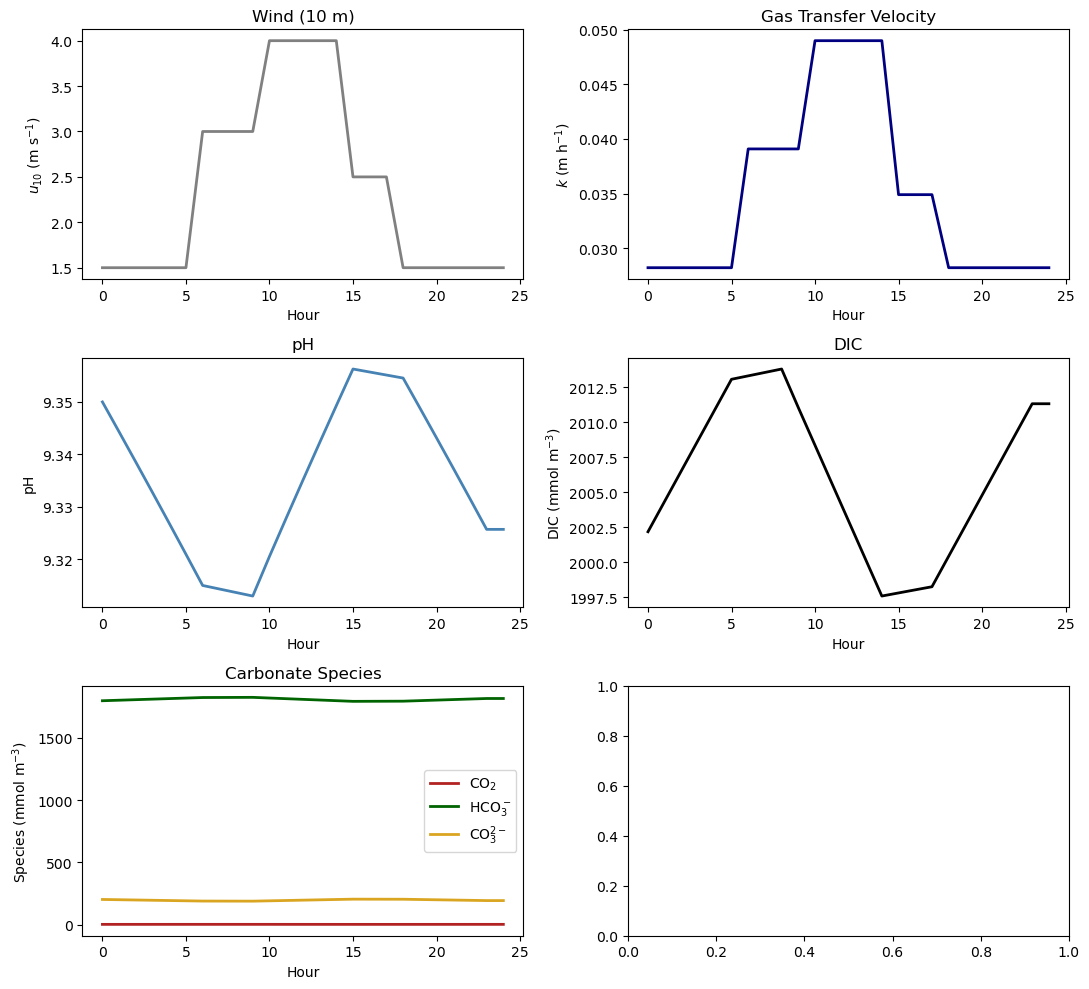

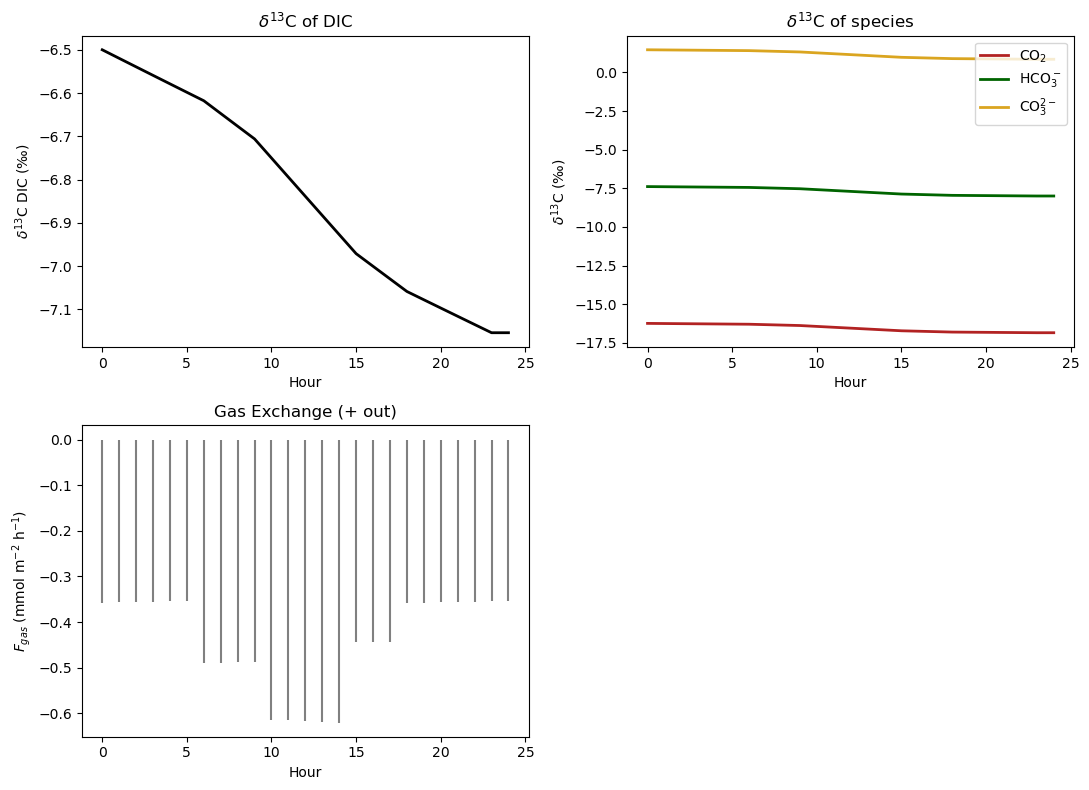

In [4]:
out = run_simulation()

print(f"Daily totals: GPP = {10*6 + 4*5 + 4*3:.1f}, R = {4*24:.1f} mmol m^-2 d^-1")
print(f"Mean u10 = {np.nanmean(out['u10'][:-1]):.2f} m s^-1 | Mean k = {np.nanmean(out['k_m_h'][:-1]):.4f} m h^-1")
print(f"Mean pH: {np.nanmean(out['pH'][:-1]):.2f} | Mean δ13C-DIC: {np.nanmean(out['delta_DIC'][:-1]):.2f} ‰")

plot_outputs(out)


## 5) Quick sensitivity examples (edit and re-run)
- Change the **HCO₃⁻ uptake fraction** `phi_HCO3` in `run_simulation(...)`.
- Switch **k parameterization**: `k_method='Wanninkhof1992'` and adjust `n_exp` (e.g., 2/3).
- Modify **wind** by passing a 24-element array to `u10_hour=...`.
- Tweak **GPP/R schedules** by passing arrays to `GPP_hour=` and `R_hour=`.
- Adjust **fractionations** at the top (ε values) for your taxa/system.


## 6 Interactive controls (ipywidgets)
Use the panel below to explore how wind, temperature, bicarbonate uptake, and fractionation choices affect DIC, pH, species, and δ¹³C dynamics.

**Note**: If `ipywidgets` is not installed in your Jupyter environment, run one of the following in a cell and restart the kernel:**

- `pip install ipywidgets`  (classic Jupyter)
- `pip install ipywidgets && jupyter nbextension enable --py widgetsnbextension`  (older classic)
- For JupyterLab 3+, `pip install ipywidgets` is usually sufficient.

In [5]:
try:
    import ipywidgets as widgets
    from ipywidgets import interact, interactive, fixed, HBox, VBox
except Exception as e:
    print('ipywidgets not available. Install with `pip install ipywidgets` and restart the kernel.')
    raise

# Helper to make a default diel wind profile from four segments
def make_wind_profile(u_night=1.5, u_morning=3.0, u_midday=4.0, u_afternoon=2.5):
    u = np.full(24, u_night, dtype=float)
    u[6:10] = u_morning
    u[10:15] = u_midday
    u[15:18] = u_afternoon
    return u

# Default diel metabolism schedules with scaling
def make_metabolism(gpp_scale=1.0, r_const=4.0):
    R_hour = np.full(24, float(r_const))
    GPP_hour = np.zeros(24)
    GPP_hour[6:9]  = 4.0 * gpp_scale
    GPP_hour[9:15] = 10.0 * gpp_scale
    GPP_hour[15:18]= 4.0 * gpp_scale
    return R_hour, GPP_hour

# Interactive runner
def run_and_plot_interactive(
    phi_HCO3=0.4, k_method='ColeCaraco1998', n_exp=0.5,
    T_C=25.0, depth_m=2.0, pCO2_uatm=420,
    DIC0_mmol_m3=2000, TA0_mmol_m3=2200,
    eps_p_CO2_val=-20.0, eps_p_HCO3_val=-10.0,
    u_night=1.5, u_morning=3.0, u_midday=4.0, u_afternoon=2.5,
    gpp_scale=1.0, r_const=4.0
):
    # Update global fractionations (used by run_simulation helpers)
    global eps_p_CO2, alpha_p_CO2, eps_p_HCO3, alpha_p_HCO3
    eps_p_CO2 = float(eps_p_CO2_val); alpha_p_CO2 = 1.0 + eps_p_CO2/1000.0
    eps_p_HCO3 = float(eps_p_HCO3_val); alpha_p_HCO3 = 1.0 + eps_p_HCO3/1000.0

    # Build wind & metabolism
    u10_hour = make_wind_profile(u_night, u_morning, u_midday, u_afternoon)
    R_hour, GPP_hour = make_metabolism(gpp_scale=gpp_scale, r_const=r_const)

    out = run_simulation(
        depth_m=depth_m, T_C=T_C, pCO2_uatm=pCO2_uatm,
        DIC0_mmol_m3=DIC0_mmol_m3, TA0_mmol_m3=TA0_mmol_m3,
        k_method=k_method, n_exp=n_exp, phi_HCO3=phi_HCO3,
        u10_hour=u10_hour, R_hour=R_hour, GPP_hour=GPP_hour
    )
    plot_outputs(out)

# UI controls
phi_slider = widgets.FloatSlider(description='φ(HCO3-)', min=0, max=1, step=0.05, value=0.4, readout_format='.2f')
k_dropdown = widgets.Dropdown(description='k method', options=['ColeCaraco1998','Wanninkhof1992'], value='ColeCaraco1998')
nexp_slider = widgets.FloatSlider(description='n (Sc exp)', min=0.3, max=0.8, step=0.05, value=0.5)
T_slider = widgets.FloatSlider(description='T (°C)', min=0, max=35, step=1, value=25)
depth_slider = widgets.FloatSlider(description='Depth (m)', min=0.5, max=10, step=0.5, value=2)
pCO2_slider = widgets.IntSlider(description='pCO2 (µatm)', min=200, max=800, step=10, value=420)
DIC_slider = widgets.IntSlider(description='DIC0 (mmol m^-3)', min=500, max=5000, step=50, value=2000)
TA_slider = widgets.IntSlider(description='TA0 (mmol m^-3)', min=500, max=5000, step=50, value=2200)
eps_co2_slider = widgets.FloatSlider(description='εp CO2 (‰)', min=-30, max=-5, step=1, value=-20)
eps_hco3_slider = widgets.FloatSlider(description='εp HCO3- (‰)', min=-20, max=0, step=1, value=-10)
uN_slider = widgets.FloatSlider(description='u_night', min=0, max=8, step=0.1, value=1.5)
uM_slider = widgets.FloatSlider(description='u_morning', min=0, max=8, step=0.1, value=3.0)
uMD_slider = widgets.FloatSlider(description='u_midday', min=0, max=12, step=0.1, value=4.0)
uA_slider = widgets.FloatSlider(description='u_afternoon', min=0, max=8, step=0.1, value=2.5)
gpp_scale_slider = widgets.FloatSlider(description='GPP scale', min=0, max=2, step=0.05, value=1.0)
r_const_slider = widgets.FloatSlider(description='R const', min=0, max=10, step=0.5, value=4.0)

ui_left = VBox([phi_slider, k_dropdown, nexp_slider, T_slider, depth_slider, pCO2_slider])
ui_mid  = VBox([DIC_slider, TA_slider, eps_co2_slider, eps_hco3_slider, gpp_scale_slider, r_const_slider])
ui_right= VBox([uN_slider, uM_slider, uMD_slider, uA_slider])
controls = HBox([ui_left, ui_mid, ui_right])

out_widget = widgets.interactive_output(run_and_plot_interactive, {
    'phi_HCO3': phi_slider,
    'k_method': k_dropdown,
    'n_exp': nexp_slider,
    'T_C': T_slider,
    'depth_m': depth_slider,
    'pCO2_uatm': pCO2_slider,
    'DIC0_mmol_m3': DIC_slider,
    'TA0_mmol_m3': TA_slider,
    'eps_p_CO2_val': eps_co2_slider,
    'eps_p_HCO3_val': eps_hco3_slider,
    'u_night': uN_slider,
    'u_morning': uM_slider,
    'u_midday': uMD_slider,
    'u_afternoon': uA_slider,
    'gpp_scale': gpp_scale_slider,
    'r_const': r_const_slider
})

display(controls, out_widget)


Output()